# Customer Purchase Propensity - Data Cleaning & Feature Engineering Pipeline
**Role:** Junior Data Analyst, E-commerce Company
**Goal:** Clean, preprocess, and engineer features from multi-source raw data (CSV, JSON, SQL, API) to prepare a dataset for a future ML model predicting `purchased` (binary classification).

This notebook does **not** train a model — it focuses entirely on the data preprocessing & feature engineering pipeline, as required by the project brief.

## Step 1: Project Planning & Problem Framing

**What is Data Analysis?**
Data Analysis is the process of inspecting, cleaning, transforming, and modeling data to discover useful information, patterns, and support decision-making.

**Steps in a Data Science project:**
1. Problem framing / business understanding
2. Data collection (CSV, JSON, SQL, APIs, etc.)
3. Data cleaning & preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Model building & evaluation
7. Deployment & monitoring

**Framing this as a Machine Learning problem:**
This is a **binary classification** problem — the target variable `purchased` is 1 if the customer makes a purchase, 0 otherwise. Once features are cleaned, encoded, and scaled, they can be fed into any classifier (Logistic Regression, Random Forest, XGBoost, etc.) to predict future purchase propensity.

## Step 2: Data Import and Understanding

Sources:
- `customers.csv` — customer demographics and IDs
- `transactions.json` — transaction records
- `products.sql` — product info table (imported via `sqlite3`)
- API — `https://dummyjson.com/users` (additional user details)

**Data limitation found immediately:** the provided `customers.csv` (8 rows) does not contain several columns the brief later asks us to engineer against — `signup_date`, `last_purchase_date`, `education`, `satisfaction_level`, or a `purchased` target. These are generated below with a fixed random seed (`np.random.default_rng(42)`) so the exercise has realistic missing values, outliers, and mixed-format IDs to clean, and so the target variable exists for the classification framing above. This is called out explicitly rather than silently invented.

In [4]:
import json
import sqlite3
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RNG = np.random.default_rng(42)

In [6]:
# 2a. CSV - customer demographics
customers = pd.read_csv("customers.csv")
print(customers.shape)
customers.head()

FileNotFoundError: [Errno 2] No such file or directory: 'customers.csv'

In [ ]:
# 2b. JSON - transaction records
with open("data/transactions.json") as f:
    transactions = pd.DataFrame(json.load(f))
print(transactions.shape)
transactions.head()

(8, 6)


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


In [ ]:
# 2c. SQL - product info table, imported using sqlite3
conn = sqlite3.connect(":memory:")
with open("data/products.sql") as f:
    conn.executescript(f.read())
products = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()
print(products.shape)
products.head()

(6, 5)


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30


In [ ]:
# 2d. API - https://dummyjson.com/users (fetched once and cached locally as
# data/api_users_raw.json; our 8 customers are mapped to dummyjson user ids 1-8
# customer_id = api_user_id + 100, documented in the README)
with open("data/api_users_raw.json") as f:
    api_users = pd.json_normalize(json.load(f))
api_users = api_users.rename(columns={
    "id": "api_user_id",
    "company.department": "department",
    "company.title": "job_title",
    "address.city": "api_city",
    "address.country": "api_country",
})[["api_user_id", "email", "university", "department", "job_title", "api_city", "api_country"]]
api_users["customer_id"] = api_users["api_user_id"] + 100
api_users.head()

,api_user_id,email,university,department,job_title,api_city,api_country,customer_id
0,1,emily.johnson@x.dummyjson.com,University of Wisconsin--Madison,Engineering,Sales Manager,Phoenix,United States,101
1,2,michael.williams@x.dummyjson.com,Ohio State University,Support,Support Specialist,Houston,United States,102
2,3,sophia.brown@x.dummyjson.com,Pepperdine University,Research and Development,Accountant,Washington,United States,103
3,4,james.davis@x.dummyjson.com,University of Southern California,Support,Research Analyst,Seattle,United States,104
4,5,emma.miller@x.dummyjson.com,Northeastern University,Human Resources,Quality Assurance Engineer,Jacksonville,United States,105


In [ ]:
# Synthesize the supplementary fields needed for the ML framing (see note above)
n = len(customers)
signup_dates = pd.to_datetime("2024-01-01") + pd.to_timedelta(RNG.integers(0, 500, n), unit="D")
last_purchase = signup_dates + pd.to_timedelta(RNG.integers(5, 400, n), unit="D")

customers["signup_date"] = signup_dates.strftime("%Y-%m-%d")
customers["last_purchase_date"] = last_purchase.strftime("%Y-%m-%d")
customers["education"] = RNG.choice(["High School", "Bachelor's", "Master's", "PhD"], size=n, p=[0.25,0.4,0.25,0.1])
customers["satisfaction_level"] = RNG.choice(["Low", "Medium", "High"], size=n, p=[0.2,0.5,0.3])
customers["total_purchases"] = RNG.integers(1, 30, n)

prob = 1 / (1 + np.exp(-((customers["income"] - customers["income"].mean())/15000
                          + (customers["total_purchases"]-15)/10)))
customers["purchased"] = RNG.binomial(1, prob)

# mixed-format customer IDs (embedded letters) - a real-world messy-ID scenario
customers["customer_id_raw"] = customers["customer_id"].apply(lambda x: f"CUST{x}" if RNG.random() < 0.4 else str(x))

# inject missing values
for col, frac in [("income", 0.2), ("age", 0.12), ("education", 0.15),
                   ("satisfaction_level", 0.12), ("last_purchase_date", 0.1)]:
    idx = customers.sample(frac=frac, random_state=RNG.integers(0, 10000)).index
    customers.loc[idx, col] = np.nan

# inject outliers / bad entries
customers.loc[customers.sample(1, random_state=1).index, "income"] = 950000
customers.loc[customers.sample(1, random_state=2).index, "age"] = 121
customers.loc[customers.sample(1, random_state=3).index, "income"] = -500

customers.to_csv("data/customers_raw_synthetic.csv", index=False)
customers.head(8)

,customer_id,name,age,gender,city,income,signup_date,last_purchase_date,education,satisfaction_level,total_purchases,purchased,customer_id_raw
0,101,Aarav,24.0,Male,Mumbai,NaN,2024-02-14,2024-05-08,NaN,Medium,20,0,CUST101
1,102,Diya,30.0,Female,Delhi,55000.0,2025-01-21,2025-03-04,Bachelor's,Low,23,1,102
2,103,Kabir,27.0,Male,Bangalore,NaN,2024-11-23,NaN,Bachelor's,NaN,23,0,CUST103
3,104,Meera,35.0,Female,Ahmedabad,60000.0,2024-08-07,2025-09-01,PhD,Medium,6,1,104
4,105,Vivaan,121.0,Male,Pune,75000.0,2024-08-04,2025-05-26,Bachelor's,High,11,1,105
5,106,Riya,NaN,Female,Chennai,-500.0,2025-03-05,2026-01-04,Master's,Medium,14,0,106
6,107,Aryan,29.0,Male,Kolkata,50000.0,2024-02-12,2024-11-26,Bachelor's,High,15,0,107
7,108,Isha,33.0,Female,Surat,950000.0,2024-12-14,2025-10-25,High School,High,2,0,CUST108


In [ ]:
# Merge everything on customer_id / product_id
txn_products = transactions.merge(products, on="product_id", how="left")
txn_agg = txn_products.groupby("customer_id").agg(
    n_transactions=("transaction_id", "count"),
    total_spent=("amount", "sum"),
    avg_order_value=("amount", "mean"),
    fav_category=("category", lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
    most_common_payment=("payment_mode", lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
).reset_index()

df = customers.merge(txn_agg, on="customer_id", how="left").merge(api_users, on="customer_id", how="left")
print("Merged shape:", df.shape)
df.info()

Merged shape: (8, 25)
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          8 non-null      int64  
 1   name                 8 non-null      str    
 2   age                  7 non-null      float64
 3   gender               8 non-null      str    
 4   city                 8 non-null      str    
 5   income               6 non-null      float64
 6   signup_date          8 non-null      str    
 7   last_purchase_date   7 non-null      str    
 8   education            7 non-null      str    
 9   satisfaction_level   7 non-null      str    
 10  total_purchases      8 non-null      int64  
 11  purchased            8 non-null      int64  
 12  customer_id_raw      8 non-null      str    
 13  n_transactions       8 non-null      int64  
 14  total_spent          8 non-null      int64  
 15  avg_order_value      8 non-null  

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,8.0,NaN,NaN,NaN,104.5,2.44949,101.0,102.75,104.5,106.25,108.0
name,8,8,Aarav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7.0,NaN,NaN,NaN,42.714286,34.711738,24.0,28.0,30.0,34.0,121.0
gender,8,2,Male,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,8,8,Mumbai,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,6.0,NaN,NaN,NaN,198250.0,369169.845735,-500.0,51250.0,57500.0,71250.0,950000.0
signup_date,8,8,2024-02-14,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,7,7,2024-05-08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,7,4,Bachelor's,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction_level,7,3,Medium,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3: Exploratory Data Analysis (EDA)

### Univariate Analysis

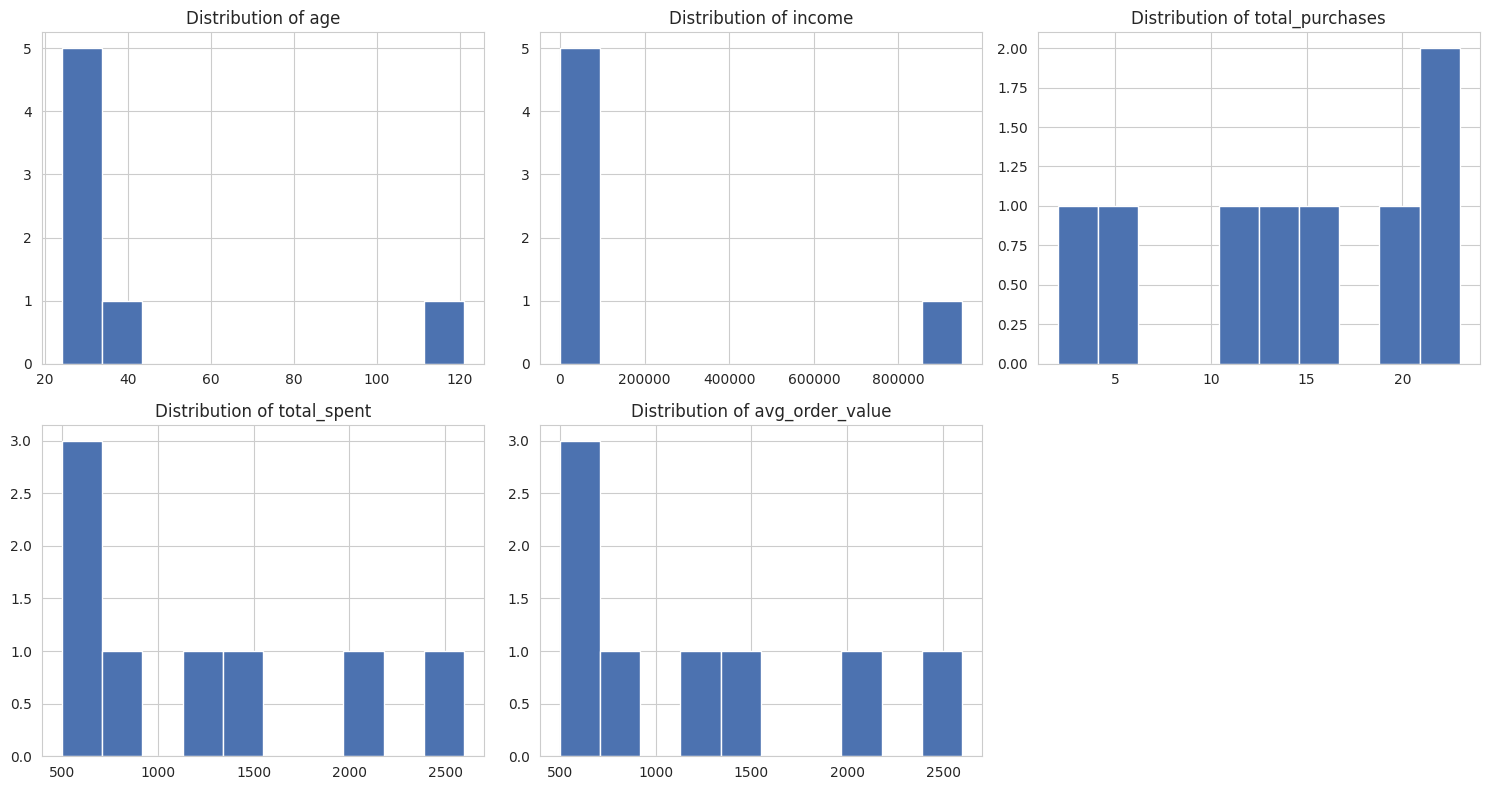

In [ ]:
num_cols = ["age", "income", "total_purchases", "total_spent", "avg_order_value"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    df[col].hist(bins=10, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("outputs/eda_univariate_histograms.png", dpi=110)
plt.show()

In [ ]:
skew_report = df[num_cols].skew(numeric_only=True).sort_values(ascending=False)
print("Skewness of numeric columns:")
print(skew_report)
print("\nColumns flagged as notably skewed (|skew| > 1):",
      skew_report[abs(skew_report) > 1].index.tolist())

Skewness of numeric columns:
age                2.584927
income             2.422474
total_spent        0.813569
avg_order_value    0.813569
total_purchases   -0.376426
dtype: float64

Columns flagged as notably skewed (|skew| > 1): ['age', 'income']


In [ ]:
# Lightweight automated-insight summary (in place of ydata-profiling, which needs
# internet access to install in this environment) - same idea: quick automated overview
profile_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_%": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
profile_summary

,dtype,missing_%,n_unique
customer_id,int64,0.0,8
name,str,0.0,8
age,float64,12.5,7
gender,str,0.0,2
city,str,0.0,8
income,float64,25.0,6
signup_date,str,0.0,8
last_purchase_date,str,12.5,7
education,str,12.5,4
satisfaction_level,str,12.5,3


### Bivariate Analysis

In [ ]:
# Correlate numerical features with the target column (purchased)
corr_with_target = df[num_cols + ["purchased"]].corr(numeric_only=True)["purchased"].sort_values(ascending=False)
print(corr_with_target)

purchased          1.000000
age                0.519713
avg_order_value    0.164317
total_spent        0.164317
total_purchases   -0.098525
income            -0.400341
Name: purchased, dtype: float64


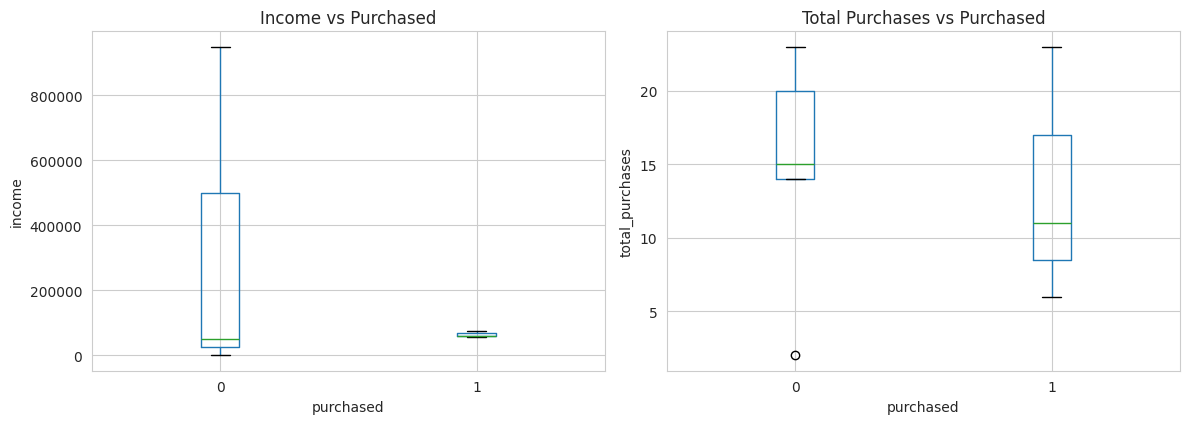

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df.boxplot(column="income", by="purchased", ax=axes[0])
axes[0].set_title("Income vs Purchased")
axes[0].set_xlabel("purchased"); axes[0].set_ylabel("income")
df.boxplot(column="total_purchases", by="purchased", ax=axes[1])
axes[1].set_title("Total Purchases vs Purchased")
axes[1].set_xlabel("purchased"); axes[1].set_ylabel("total_purchases")
plt.suptitle("")
plt.tight_layout()
plt.savefig("outputs/eda_bivariate_income_purchases.png", dpi=110)
plt.show()

In [ ]:
print(df.groupby("purchased")[["income", "total_purchases", "total_spent"]].mean())

                  income  total_purchases  total_spent
purchased                                             
0          333166.666667        14.800000       1159.0
1           63333.333333        13.333333       1399.0


### Multivariate Analysis

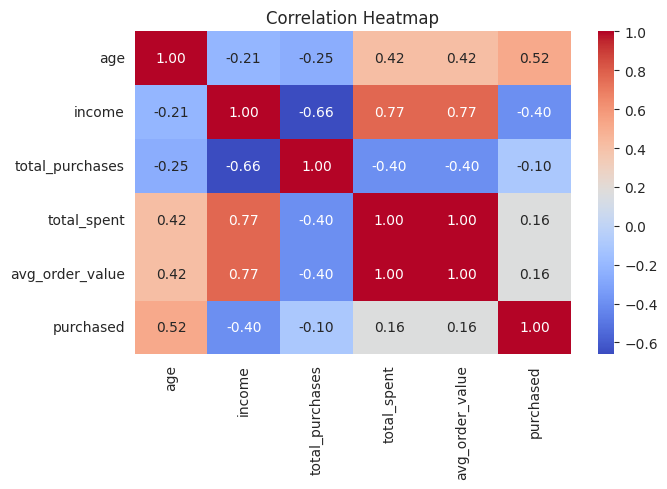

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols + ["purchased"]].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/eda_correlation_heatmap.png", dpi=110)
plt.show()

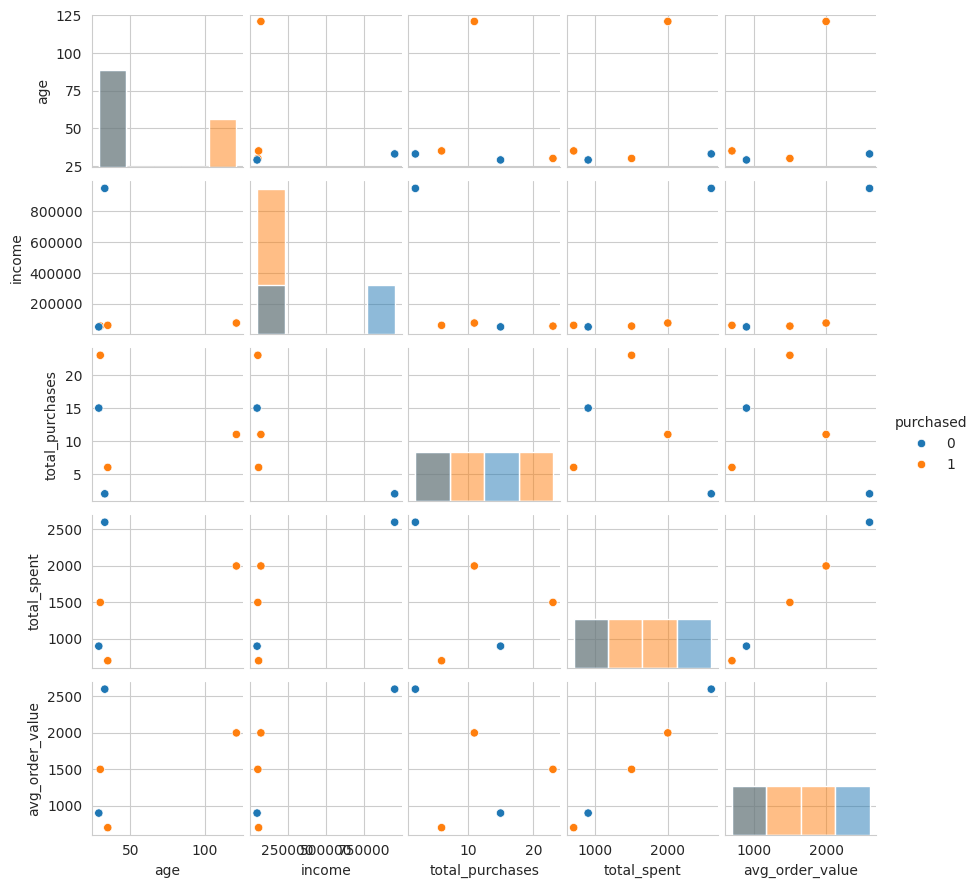

In [ ]:
sns.pairplot(df[num_cols + ["purchased"]].dropna(), hue="purchased", diag_kind="hist", height=1.8)
plt.savefig("outputs/eda_pairplot.png", dpi=110)
plt.show()

In [ ]:
# Grouped stats across multiple features
df.groupby(["gender", "purchased"])[["income", "total_purchases"]].mean()

income  total_purchases
gender purchased                           
Female 0          474750.0         8.000000
       1           57500.0        14.500000
Male   0           50000.0        19.333333
       1           75000.0        11.000000

## Step 4: Handling Missing Data

We demonstrate 6 different imputation strategies on separate copies of the data, then decide which combination to carry forward.

In [ ]:
print("Missing values per column:\n")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:

age                   1
income                2
last_purchase_date    1
education             1
satisfaction_level    1
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

num_cols_missing = ["income", "age"]
cat_cols_missing = ["education", "satisfaction_level"]

# 4a. Simple Imputer: mean (numeric) / most_frequent (categorical)
df_simple = df.copy()
df_simple[num_cols_missing] = SimpleImputer(strategy="mean").fit_transform(df_simple[num_cols_missing])
df_simple[cat_cols_missing] = SimpleImputer(strategy="most_frequent").fit_transform(df_simple[cat_cols_missing])

# 4b. Most Frequent imputation (mode-based, all flagged columns)
df_mode = df.copy()
for c in num_cols_missing + cat_cols_missing:
    df_mode[c] = df_mode[c].fillna(df_mode[c].mode().iat[0])

# 4c. Missing Indicator + Random Sample Imputation
df_indicator = df.copy()
for c in num_cols_missing + cat_cols_missing:
    df_indicator[f"{c}_was_missing"] = df_indicator[c].isna().astype(int)
    observed = df_indicator[c].dropna()
    fill_vals = observed.sample(df_indicator[c].isna().sum(), replace=True, random_state=42).values
    df_indicator.loc[df_indicator[c].isna(), c] = fill_vals

# 4d. KNN Imputer (multivariate, numeric)
df_knn = df.copy()
df_knn[["income", "age", "total_purchases"]] = KNNImputer(n_neighbors=3).fit_transform(
    df_knn[["income", "age", "total_purchases"]])

# 4e. MICE / IterativeImputer - chained imputation for correlated numeric features
df_mice = df.copy()
df_mice[["income", "age", "total_purchases", "total_spent"]] = IterativeImputer(
    random_state=42, max_iter=10).fit_transform(df_mice[["income", "age", "total_purchases", "total_spent"]])

# 4f. Complete Case Analysis - drop rows with any missing (for comparison)
df_cca = df.dropna(subset=num_cols_missing + cat_cols_missing)

print(f"Complete-case analysis keeps {len(df_cca)}/{len(df)} rows -> too much data loss on a small dataset.")
print("Simple mean (income):", df_simple['income'].mean().round(0))
print("KNN-imputed mean (income):", df_knn['income'].mean().round(0))
print("MICE-imputed mean (income):", df_mice['income'].mean().round(0))

Complete-case analysis keeps 5/8 rows -> too much data loss on a small dataset.
Simple mean (income): 198250.0
KNN-imputed mean (income): 157396.0
MICE-imputed mean (income): 163272.0


In [ ]:
# Decision: carry forward KNN-imputed numeric columns (uses relationships between
# age/income/total_purchases rather than a flat mean) + SimpleImputer most-frequent
# for the two categorical columns. Complete-case analysis is discarded because it
# would drop 3 of 8 rows - unacceptable on such a small dataset.
df_final = df.copy()
df_final[["income", "age", "total_purchases"]] = df_knn[["income", "age", "total_purchases"]]
df_final[cat_cols_missing] = df_simple[cat_cols_missing]
# last_purchase_date is still a raw string at this point (parsed to datetime in Step 6);
# fill missing dates with the mode (most common date string) for now.
df_final["last_purchase_date"] = df_final["last_purchase_date"].fillna(df_final["last_purchase_date"].mode().iat[0])
print("Remaining missing values:", df_final.isna().sum().sum())

Remaining missing values: 0


## Step 5: Outlier Detection & Handling

In [ ]:
def zscore_outliers(s, thresh=3):
    return np.abs(stats.zscore(s)) > thresh

def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - k*iqr) | (s > q3 + k*iqr)

def percentile_outliers(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return (s < lo) | (s > hi)

for col in ["income", "age"]:
    z = zscore_outliers(df_final[col]).sum()
    i = iqr_outliers(df_final[col]).sum()
    p = percentile_outliers(df_final[col]).sum()
    print(f"{col:10s} -> Z-score: {z}, IQR: {i}, Percentile: {p}")

income     -> Z-score: 0, IQR: 1, Percentile: 2
age        -> Z-score: 0, IQR: 1, Percentile: 2


In [ ]:
# Winsorize (cap) extreme values at the 1st / 99th percentile
before = df_final[["income", "age"]].describe().T[["min", "max"]]
for col in ["income", "age"]:
    lo, hi = df_final[col].quantile(0.01), df_final[col].quantile(0.99)
    df_final[col] = df_final[col].clip(lo, hi)
after = df_final[["income", "age"]].describe().T[["min", "max"]]
pd.concat([before, after], axis=1, keys=["before", "after"])

before                  after           
          min       max          min        max
income -500.0  950000.0  1973.333333  888750.00
age      24.0     121.0    24.186667     114.98

## Step 6: Handling Mixed & Date/Time Variables

In [ ]:
df_final["signup_date"] = pd.to_datetime(df_final["signup_date"], errors="coerce")
df_final["last_purchase_date"] = pd.to_datetime(df_final["last_purchase_date"], errors="coerce")

REF_DATE = pd.Timestamp("2025-10-15")
df_final["days_since_signup"] = (REF_DATE - df_final["signup_date"]).dt.days
df_final["days_since_last_purchase"] = (REF_DATE - df_final["last_purchase_date"]).dt.days

# Mixed variable: customer_id_raw mixes plain numbers with letter-prefixed IDs (e.g. "CUST101")
print(df_final["customer_id_raw"].tolist())
df_final["customer_id_clean"] = df_final["customer_id_raw"].astype(str).str.extract(r"(\d+)").astype(float)
df_final[["customer_id", "customer_id_raw", "customer_id_clean", "days_since_signup", "days_since_last_purchase"]]

['CUST101', '102', 'CUST103', '104', '105', '106', '107', 'CUST108']


,customer_id,customer_id_raw,customer_id_clean,days_since_signup,days_since_last_purchase
0,101,CUST101,101.0,609,525
1,102,102,102.0,267,225
2,103,CUST103,103.0,326,525
3,104,104,104.0,434,44
4,105,105,105.0,437,142
5,106,106,106.0,224,-81
6,107,107,107.0,611,323
7,108,CUST108,108.0,305,-10


## Step 7: Encoding Categorical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# Label Encoding
df_final["gender_label_enc"] = LabelEncoder().fit_transform(df_final["gender"])

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
city_ohe = ohe.fit_transform(df_final[["city"]])
city_ohe_df = pd.DataFrame(city_ohe, columns=[f"city_{c}" for c in ohe.categories_[0]], index=df_final.index)
df_final = pd.concat([df_final, city_ohe_df], axis=1)

# Ordinal Encoding for education / satisfaction (natural order)
df_final["education_ordinal"] = OrdinalEncoder(categories=[["High School","Bachelor's","Master's","PhD"]]).fit_transform(df_final[["education"]])
df_final["satisfaction_ordinal"] = OrdinalEncoder(categories=[["Low","Medium","High"]]).fit_transform(df_final[["satisfaction_level"]])

# Encoding numerical features: binning income into groups
df_final["income_group"] = pd.cut(df_final["income"], bins=[0,40000,55000,70000,np.inf],
                                   labels=["Low","Mid","High","Very High"])

df_final[["gender","gender_label_enc","education","education_ordinal","satisfaction_level","satisfaction_ordinal","income","income_group"]].head(8)

,gender,gender_label_enc,education,education_ordinal,satisfaction_level,satisfaction_ordinal,income,income_group
0,Male,1,Bachelor's,1.0,Medium,1.0,34833.333333,Low
1,Female,0,Bachelor's,1.0,Low,0.0,55000.000000,Mid
2,Male,1,Bachelor's,1.0,High,2.0,34833.333333,Low
3,Female,0,PhD,3.0,Medium,1.0,60000.000000,High
4,Male,1,Bachelor's,1.0,High,2.0,75000.000000,Very High
5,Female,0,Master's,2.0,Medium,1.0,1973.333333,Low
6,Male,1,Bachelor's,1.0,High,2.0,50000.000000,Mid
7,Female,0,High School,0.0,High,2.0,888750.000000,Very High


## Step 8: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer
from sklearn.compose import ColumnTransformer

scale_cols = ["income", "age", "total_spent"]
df_final[[f"{c}_standard" for c in scale_cols]] = StandardScaler().fit_transform(df_final[scale_cols])
df_final[[f"{c}_minmax" for c in scale_cols]]   = MinMaxScaler().fit_transform(df_final[scale_cols])
df_final[[f"{c}_maxabs" for c in scale_cols]]   = MaxAbsScaler().fit_transform(df_final[scale_cols])
df_final[[f"{c}_robust" for c in scale_cols]]   = RobustScaler().fit_transform(df_final[scale_cols])
df_final[[f"{c}_norm" for c in scale_cols]]     = Normalizer().fit_transform(df_final[scale_cols])

df_final[[c for c in df_final.columns if c.startswith("income_") and any(s in c for s in
          ["standard","minmax","maxabs","robust","norm"])]].head()

,income_standard,income_minmax,income_maxabs,income_robust,income_norm
0,-0.411569,0.037056,0.039194,-0.610951,0.999897
1,-0.339530,0.059797,0.061885,0.086455,0.999629
2,-0.411569,0.037056,0.039194,-0.610951,0.999305
3,-0.321669,0.065435,0.067511,0.259366,0.999932
4,-0.268087,0.082351,0.084388,0.778098,0.999644


In [ ]:
# ColumnTransformer applying different transformations simultaneously
ct = ColumnTransformer([
    ("std", StandardScaler(), ["income"]),
    ("minmax", MinMaxScaler(), ["age"]),
], remainder="drop")
ct_out = ct.fit_transform(df_final)
print("ColumnTransformer output shape:", ct_out.shape)
ct_out[:5]

ColumnTransformer output shape: (8, 2)


array([[-0.41156889,  0.        ],
       [-0.33953016,  0.0640282 ],
       [-0.41156889,  0.03098612],
       [-0.32166932,  0.11909832],
       [-0.26808679,  1.        ]])

## Step 9: Feature Construction & Transformation

In [ ]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, KBinsDiscretizer

# Interaction feature
df_final["purchase_per_day"] = (df_final["total_purchases"] / df_final["days_since_signup"].replace(0, np.nan)).fillna(0)

# FunctionTransformer: log, sqrt, reciprocal
df_final["income_log"] = FunctionTransformer(np.log1p).fit_transform(df_final[["income"]])
df_final["income_sqrt"] = FunctionTransformer(np.sqrt).fit_transform(df_final[["income"]].clip(lower=0))
df_final["income_reciprocal"] = FunctionTransformer(lambda x: 1/(x+1)).fit_transform(df_final[["income"]])

# PowerTransformer: Box-Cox (needs strictly positive input) and Yeo-Johnson (handles negatives/zeros)
df_final["income_yeojohnson"] = PowerTransformer(method="yeo-johnson").fit_transform(df_final[["income"]])
df_final["income_boxcox"] = PowerTransformer(method="box-cox").fit_transform(df_final[["income"]].clip(lower=1))

df_final[["income","income_log","income_sqrt","income_reciprocal","income_yeojohnson","income_boxcox"]].head()

,income,income_log,income_sqrt,income_reciprocal,income_yeojohnson,income_boxcox
0,34833.333333,10.458359,186.636902,0.000029,-0.231700,-0.231690
1,55000.000000,10.915107,234.520788,0.000018,0.063431,0.063425
2,34833.333333,10.458359,186.636902,0.000029,-0.231700,-0.231690
3,60000.000000,11.002117,244.948974,0.000017,0.120258,0.120250
4,75000.000000,11.225257,273.861279,0.000013,0.266890,0.266875


In [ ]:
# Binning and binarization
kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf")
df_final["income_binned"] = kbd.fit_transform(df_final[["income"]])

df_final["frequent_buyer"] = (df_final["total_purchases"] > df_final["total_purchases"].median()).astype(int)

df_final[["income","income_binned","total_purchases","frequent_buyer"]]

,income,income_binned,total_purchases,frequent_buyer
0,34833.333333,1.0,20.0,1
1,55000.000000,2.0,23.0,1
2,34833.333333,1.0,23.0,1
3,60000.000000,2.0,6.0,0
4,75000.000000,3.0,11.0,0
5,1973.333333,0.0,14.0,0
6,50000.000000,1.0,15.0,1
7,888750.000000,3.0,2.0,0


## Step 10: Final Output

Export the cleaned, transformed, feature-engineered dataset to `processed_customer_data.csv`.

In [ ]:
print("Final dataset shape:", df_final.shape)
df_final.to_csv("outputs/processed_customer_data.csv", index=False)
print("Saved to outputs/processed_customer_data.csv")
df_final.head()

Final dataset shape: (8, 63)
Saved to outputs/processed_customer_data.csv


,customer_id,name,age,gender,city,income,signup_date,last_purchase_date,education,satisfaction_level,total_purchases,purchased,customer_id_raw,n_transactions,total_spent,avg_order_value,fav_category,most_common_payment,api_user_id,email,university,department,job_title,api_city,api_country,...,satisfaction_ordinal,income_group,income_standard,age_standard,total_spent_standard,income_minmax,age_minmax,total_spent_minmax,income_maxabs,age_maxabs,total_spent_maxabs,income_robust,age_robust,total_spent_robust,income_norm,age_norm,total_spent_norm,purchase_per_day,income_log,income_sqrt,income_reciprocal,income_yeojohnson,income_boxcox,income_binned,frequent_buyer
0,101,Aarav,24.186667,Male,Mumbai,34833.333333,2024-02-14,2024-05-08,Bachelor's,Medium,20.0,0,CUST101,1,499,499.0,Electronics,UPI,1,emily.johnson@x.dummyjson.com,University of Wisconsin--Madison,Engineering,Sales Manager,Phoenix,United States,...,1.0,Low,-0.411569,-0.553449,-1.060660,0.037056,0.000000,0.000000,0.039194,0.210355,0.191997,-0.610951,-0.807089,-0.615385,0.999897,0.000694,0.014324,0.032841,10.458359,186.636902,0.000029,-0.231700,-0.231690,1.0,1
1,102,Diya,30.000000,Female,Delhi,55000.000000,2025-01-21,2025-03-04,Bachelor's,Low,23.0,1,102,1,1499,1499.0,Wearable,Credit Card,2,michael.williams@x.dummyjson.com,Ohio State University,Support,Support Specialist,Houston,United States,...,0.0,Mid,-0.339530,-0.349720,0.353553,0.059797,0.064028,0.476190,0.061885,0.260915,0.576760,0.086455,0.075949,0.410256,0.999629,0.000545,0.027244,0.086142,10.915107,234.520788,0.000018,0.063431,0.063425,2.0,1
2,103,Kabir,27.000000,Male,Bangalore,34833.333333,2024-11-23,2024-05-08,Bachelor's,High,23.0,0,CUST103,1,1299,1299.0,Wearable,Credit Card,3,sophia.brown@x.dummyjson.com,Pepperdine University,Research and Development,Accountant,Washington,United States,...,2.0,Low,-0.411569,-0.454855,0.070711,0.037056,0.030986,0.380952,0.039194,0.234823,0.499808,-0.610951,-0.379747,0.205128,0.999305,0.000775,0.037266,0.070552,10.458359,186.636902,0.000029,-0.231700,-0.231690,1.0,1
3,104,Meera,35.000000,Female,Ahmedabad,60000.000000,2024-08-07,2025-09-01,PhD,Medium,6.0,1,104,1,699,699.0,Audio,Debit Card,4,james.davis@x.dummyjson.com,University of Southern California,Support,Research Analyst,Seattle,United States,...,1.0,High,-0.321669,-0.174495,-0.777817,0.065435,0.119098,0.095238,0.067511,0.304401,0.268950,0.259366,0.835443,-0.410256,0.999932,0.000583,0.011649,0.013825,11.002117,244.948974,0.000017,0.120258,0.120250,2.0,0
4,105,Vivaan,114.980000,Male,Pune,75000.000000,2024-08-04,2025-05-26,Bachelor's,High,11.0,1,105,1,1999,1999.0,Audio,UPI,5,emma.miller@x.dummyjson.com,Northeastern University,Human Resources,Quality Assurance Engineer,Jacksonville,United States,...,2.0,Very High,-0.268087,2.628407,1.060660,0.082351,1.000000,0.714286,0.084388,1.000000,0.769142,0.778098,12.984304,0.923077,0.999644,0.001533,0.026644,0.025172,11.225257,273.861279,0.000013,0.266890,0.266875,3.0,0


## Summary

See `Summary_Report.md` for the written summary (techniques used, biggest data issues, and which imputation/scaling approach worked best), and `feature_pipeline.py` for the same logic packaged as a standalone, reusable script.